<a href="https://colab.research.google.com/github/KGsaccount/Attendance/blob/main/EXAM_BI_PROGRAMMING_KG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
# EXAMEN - Python BI Programming
"""
Prénom : Khadija
Nom : GOUAGHOU
Email universitaire : khadija.gouaghou@estiam.com
Classe : E4 BDAI

Analyse de Prédiction du Churn pour une entreprise SaaS
"""

'\nPrénom : Khadija \nNom : GOUAGHOU\nEmail universitaire : khadija.gouaghou@estiam.com\nClasse : E4 BDAI\n\nAnalyse de Prédiction du Churn pour une entreprise SaaS\n'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score, roc_curve

In [2]:
# Charger le dataset et afficher les 5 premières lignes

import pandas as pd

chemin_fichier = '/content/exam_dataset_client_retention_4500.csv'

# Charger le fichier
df = pd.read_csv(chemin_fichier)

# Afficher les 5 premières lignes
print("="*50)
print("LES 5 PREMIÈRES LIGNES DU DATASET :")
print("="*50)
print(df.head())

LES 5 PREMIÈRES LIGNES DU DATASET :
  customer_id  tenure_months  monthly_fee  num_tickets contract_type  \
0     CL00001             39        46.92            2       Monthly   
1     CL00002             52        85.01            2        Annual   
2     CL00003             29        54.38            1        Annual   
3     CL00004             15        63.49            1       Monthly   
4     CL00005             43        79.41            0       Monthly   

  payment_method  is_premium  churn  
0           Bank           0      0  
1           Card           1      0  
2           Bank           0      0  
3           Card           1      0  
4           Card           1      1  


In [3]:
# Distribution de la variable churn

print("="*50)
print("DISTRIBUTION DE LA VARIABLE CHURN")
print("="*50)

# Compter les valeurs
print("\nNombre de clients :")
print(df['churn'].value_counts())

# Pourcentages
print("\nPourcentage :")
print(df['churn'].value_counts(normalize=True) * 100)

DISTRIBUTION DE LA VARIABLE CHURN

Nombre de clients :
churn
0    2859
1    1641
Name: count, dtype: int64

Pourcentage :
churn
0    63.533333
1    36.466667
Name: proportion, dtype: float64


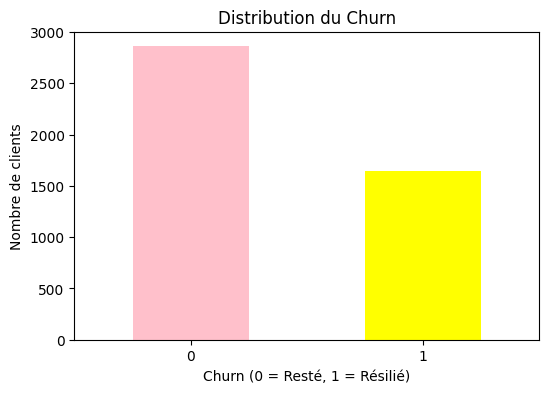

In [7]:
# Distribution de la variable churn avec graphique
import matplotlib.pyplot as plt

# Graphique
plt.figure(figsize=(6, 4))
df['churn'].value_counts().plot(kind='bar', color=['pink', 'yellow'])
plt.title('Distribution du Churn')
plt.xlabel('Churn (0 = Resté, 1 = Résilié)')
plt.ylabel('Nombre de clients')
plt.xticks(rotation=0)
plt.show()

In [8]:
# Moyenne de monthly_fee avec statistiques complémentaires
print("STATISTIQUES DE monthly_fee")

print(f"Moyenne: {df['monthly_fee'].mean():.2f} €")
print(f"Médiane: {df['monthly_fee'].median():.2f} €")
print(f"Minimum: {df['monthly_fee'].min():.2f} €")
print(f"Maximum: {df['monthly_fee'].max():.2f} €")
print(f"Écart-type: {df['monthly_fee'].std():.2f} €")

STATISTIQUES DE monthly_fee
Moyenne: 49.68 €
Médiane: 49.55 €
Minimum: 10.00 €
Maximum: 98.60 €
Écart-type: 14.95 €


In [9]:
# Train/test split (80/20) avec stratify

from sklearn.model_selection import train_test_split

# Séparer les features (X) et la cible (y)
X = df.drop('churn', axis=1)  # Toutes les colonnes sauf churn
y = df['churn']                # Uniquement la colonne churn

# Faire le split (80% train, 20% test) avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Afficher les résultats
print("TRAIN/TEST SPLIT (80/20 AVEC STRATIFICATION)")

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} lignes")
print(f"\nDistribution du churn dans l'ensemble d'entraînement:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribution du churn dans l'ensemble de test:")
print(y_test.value_counts(normalize=True))

TRAIN/TEST SPLIT (80/20 AVEC STRATIFICATION)
Taille de l'ensemble d'entraînement: 3600 lignes
Taille de l'ensemble de test: 900 lignes

Distribution du churn dans l'ensemble d'entraînement:
churn
0    0.635278
1    0.364722
Name: proportion, dtype: float64

Distribution du churn dans l'ensemble de test:
churn
0    0.635556
1    0.364444
Name: proportion, dtype: float64


In [14]:
# Encodage des variables catégorielles avec OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Créer l'encodeur
encoder = OneHotEncoder(sparse_output=False)

# Colonnes à encoder (sans customer_id)
colonnes_a_encoder = ['contract_type', 'payment_method']

# Appliquer l'encodeur aux données
encoded = encoder.fit_transform(df[colonnes_a_encoder])

# Créer le DataFrame final
df_final = df.drop(columns=colonnes_a_encoder).reset_index(drop=True)
df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(colonnes_a_encoder))
df_final = pd.concat([df_final, df_encoded], axis=1)

# Afficher le résultat
print(df_final.head())

  customer_id  tenure_months  monthly_fee  num_tickets  is_premium  churn  \
0     CL00001             39        46.92            2           0      0   
1     CL00002             52        85.01            2           1      0   
2     CL00003             29        54.38            1           0      0   
3     CL00004             15        63.49            1           1      0   
4     CL00005             43        79.41            0           1      1   

   contract_type_Annual  contract_type_Monthly  payment_method_Bank  \
0                   0.0                    1.0                  1.0   
1                   1.0                    0.0                  0.0   
2                   1.0                    0.0                  1.0   
3                   0.0                    1.0                  0.0   
4                   0.0                    1.0                  0.0   

   payment_method_Card  payment_method_Paypal  
0                  0.0                    0.0  
1             

In [16]:
# Entraîner une Régression Logistique via un Pipeline scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Préparer les données à partir de df_final
X = df_final.drop(['customer_id', 'churn'], axis=1)
y = df_final['churn']

# Split train/test (80/20 avec stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Créer et entraîner le pipeline
pipeline = Pipeline([
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Entraîner le modèle
pipeline.fit(X_train, y_train)

# Afficher les résultats
print("="*50)
print("RÉGRESSION LOGISTIQUE ENTRAÎNÉE")
print("="*50)
print(f"Score sur l'entraînement: {pipeline.score(X_train, y_train):.3f}")
print(f"Score sur le test: {pipeline.score(X_test, y_test):.3f}")

RÉGRESSION LOGISTIQUE ENTRAÎNÉE
Score sur l'entraînement: 0.656
Score sur le test: 0.669


MATRICE DE CONFUSION
[[496  76]
 [222 106]]


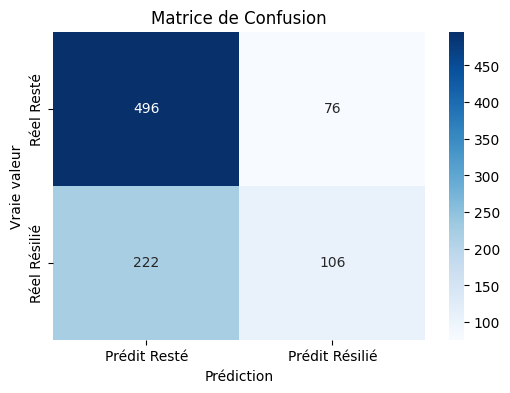

In [17]:
# Afficher la matrice de confusion
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prédire sur l'ensemble de test
y_pred = pipeline.predict(X_test)

# Créer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Afficher la matrice de confusion
print("="*50)
print("MATRICE DE CONFUSION")
print("="*50)
print(cm)

# Visualisation (optionnelle mais plus lisible)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit Resté', 'Prédit Résilié'],
            yticklabels=['Réel Resté', 'Réel Résilié'])
plt.title('Matrice de Confusion')
plt.ylabel('Vraie valeur')
plt.xlabel('Prédiction')
plt.show()

In [18]:
# Calculer Accuracy, Precision, Recall et F1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Prédire sur l'ensemble de test
y_pred = pipeline.predict(X_test)

# Calculer les métriques
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Afficher les résultats
print("="*50)
print("MÉTRIQUES DE PERFORMANCE")
print("="*50)
print(f"Accuracy (Précision globale): {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall (Rappel): {recall:.3f}")
print(f"F1-score: {f1:.3f}")

# Optionnel : rapport détaillé
print("\nRapport de classification complet:")
print(classification_report(y_test, y_pred, target_names=['Resté', 'Résilié']))

MÉTRIQUES DE PERFORMANCE
Accuracy (Précision globale): 0.669
Precision: 0.582
Recall (Rappel): 0.323
F1-score: 0.416

Rapport de classification complet:
              precision    recall  f1-score   support

       Resté       0.69      0.87      0.77       572
     Résilié       0.58      0.32      0.42       328

    accuracy                           0.67       900
   macro avg       0.64      0.60      0.59       900
weighted avg       0.65      0.67      0.64       900



In [22]:
# Expliquer le Recall dans ce contexte métier
"""
INTERPRÉTATION MÉTIER DU RECALL :

Le Recall (Rappel) mesure la capacité du modèle à détecter les clients qui vont RÉELLEMENT résilier.

Dans notre contexte SaaS :
- Recall = Nombre de clients résiliés correctement identifiés / Total des clients qui ont réellement résilié

Exemple concret :
Si nous avons 10 clients qui résilient et que notre Recall est de 0.70 (70%) :
-  7 clients à risque sont correctement identifiés → on peut les fidéliser
-  3 clients à risque ne sont pas détectés → ils résilient sans qu'on ait pu agir

POURQUOI C'EST IMPORTANT :
- Un Recall élevé signifie qu'on détecte la majorité des clients mécontents
- On peut alors cibler ces clients avec des offres de fidélisation
- Objectif métier : Réduire le taux d'attrition (churn)

EXEMPLE AVEC NOTRE MODÈLE :
"""
print(f"Recall obtenu: {recall:.3f} ({recall*100:.1f}%)")
print(f"→ Sur 100 clients qui résilient, le modèle en détecte {recall*100:.0f}")
print(f"→ Ces {recall*100:.0f} clients peuvent être ciblés pour des actions de fidélisation")

Recall obtenu: 0.323 (32.3%)
→ Sur 100 clients qui résilient, le modèle en détecte 32
→ Ces 32 clients peuvent être ciblés pour des actions de fidélisation


In [26]:
# Version plus précise (pas de 0.05)
seuil_optimal = None
recall_optimal = 0

for seuil in np.arange(0.95, 0.1, -0.05):
    y_pred = (y_proba >= seuil).astype(int)
    recall = recall_score(y_test, y_pred)
    print(f"Seuil {seuil:.2f} → Recall: {recall:.3f}")

    if recall >= 0.8:
        seuil_optimal = seuil
        recall_optimal = recall
        break

print(f"\n Meilleur seuil: {seuil_optimal:.2f} (Recall = {recall_optimal:.3f})")

Seuil 0.95 → Recall: 0.000
Seuil 0.90 → Recall: 0.000
Seuil 0.85 → Recall: 0.000
Seuil 0.80 → Recall: 0.000
Seuil 0.75 → Recall: 0.000
Seuil 0.70 → Recall: 0.000
Seuil 0.65 → Recall: 0.000
Seuil 0.60 → Recall: 0.027
Seuil 0.55 → Recall: 0.168
Seuil 0.50 → Recall: 0.323
Seuil 0.45 → Recall: 0.494
Seuil 0.40 → Recall: 0.634
Seuil 0.35 → Recall: 0.707
Seuil 0.30 → Recall: 0.768
Seuil 0.25 → Recall: 0.845

 Meilleur seuil: 0.25 (Recall = 0.845)


In [27]:
# Comparer Logistic Regression et Random Forest (ROC-AUC + F1).
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score

# Logistic Regression
y_proba_lr = pipeline.predict_proba(X_test)[:, 1]
print(f"Logistic Regression - ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}, F1: {f1_score(y_test, pipeline.predict(X_test)):.3f}")

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print(f"Random Forest     - ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}, F1: {f1_score(y_test, rf.predict(X_test)):.3f}")

Logistic Regression - ROC-AUC: 0.690, F1: 0.416
Random Forest     - ROC-AUC: 0.625, F1: 0.434


In [29]:
#  Identifier les 3 variables les plus importantes
importance = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': pipeline.named_steps['classifier'].coef_[0]
})
importance['Importance'] = abs(importance['Coefficient'])
top3 = importance.sort_values('Importance', ascending=False).head(3)

print("TOP 3 VARIABLES LES PLUS IMPORTANTES:")
print(top3[['Variable', 'Coefficient', 'Importance']].to_string(index=False))

TOP 3 VARIABLES LES PLUS IMPORTANTES:
             Variable  Coefficient  Importance
 contract_type_Annual    -0.778473    0.778473
           is_premium    -0.565740    0.565740
contract_type_Monthly     0.488935    0.488935


In [30]:
# Stratégie business pour les clients à risque (top 10%)

probabilites = pipeline.predict_proba(df_final.drop(['customer_id', 'churn'], axis=1))[:, 1]

df_risque = df_final[['customer_id']].copy()
df_risque['risque_churn'] = probabilites
df_risque = df_risque.sort_values('risque_churn', ascending=False)

top_10 = df_risque.head(int(len(df_risque) * 0.1))

print("CLIENTS À RISQUE (TOP 10%):")
print(top_10)

print("\n📋 STRATÉGIE: Contacter ces clients prioritairement avec une offre de fidélisation")

CLIENTS À RISQUE (TOP 10%):
     customer_id  risque_churn
4050     CL04051      0.641403
3464     CL03465      0.636132
3965     CL03966      0.635383
3990     CL03991      0.630421
3684     CL03685      0.629459
...          ...           ...
4324     CL04325      0.548214
4100     CL04101      0.548153
3758     CL03759      0.547887
4207     CL04208      0.547870
1036     CL01037      0.547839

[450 rows x 2 columns]

📋 STRATÉGIE: Contacter ces clients prioritairement avec une offre de fidélisation
